# Single-Cell RNA-seq DEG Analysis and Visualization

## SUMMARY
1. Load and preprocess single-cell AnnData objects for DEG analysis  
2. Perform DEG calculations with internal and external references  
3. Visualize DEGs using heatmaps, dotplots, split dotplots, violins, and UMAPs
    - Cluster annotation - per leiden cluster degs
    - Condition-level analysis - Within one cluster condition degs 
5. Configure automated downstream plotting and export results  

### 1. Data Loading
- Load clustered single-cell `.h5ad` file into AnnData object  
- Configure matplotlib display settings  

### 2. Preprocessing & Log Transformation
- Create unbiased `log2_count` layer to avoid normalization distortions  
- Run downstream preprocessing with gene set references  

### 3. DEG Calculation
- Compute DEGs across clusters with hierarchical clustering  
- Excursus: compare DEGs against global external references for robustness  

### 4. Hallmark & Heatmap Analysis
- Generate hallmark heatmaps to summarize cluster-specific pathways  

### 5. Condition-Specific DEG Analysis
- Run flexible DEG comparisons across clusters and conditions  
- Support for explicit group–reference pairs or automated sweeps  

### 6. Split Dotplots
- Visualize gene expression split by conditions within clusters  
- Explore scaling, normalization, and DEG-only subsetting for clarity  

### 7. Dotplot Enhancements
- Support hierarchical grouping of marker sets  
- Handle overlapping groups and unique gene identifiers  

### 8. Validation & Comparisons
- Compare marginal expression differences for candidate genes  
- Explore violin plots and UMAP side-by-side for condition effects  

### 9. Automated Downstream Configuration
- Configure heatmaps, violins, dotplots, gradients via `adata.uns["config"]`  
- Enable categorical density plots for selected `obs` keys  

### 10. Saving & Reporting
- Run `sc_code.run_downstream` for automated plots/CSVs  
- Save processed AnnData with DEG results




# Imports

In [1]:
# Enable autoreloading, delete this for deploying!!!
%load_ext autoreload
%autoreload 2
%load_ext memory_profiler

In [2]:
%%time
import os  # Provides functions to interact with the operating system


# NOTE: UNCOMMENT IF NO GPU AVAILABLE!
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Adjust device IDs as per your setup,

# IBMS Libraries
from scToolkit import sc_code
from scToolkit import sc_config
from scToolkit import sc_plots
from scToolkit import sc_utils
from scToolkit import utils


# Some libraries (e.g., decoupler) may require setting rarely used parallelization
# backends. This function ensures all common thread settings are configured.
# utils.set_threads(10)


/projects/Research/Internal/Proximap/ssd/envs/scToolkit_check_TD/proximap_stable_28_08_2025/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


CUDA devices visible: 0
CPU times: user 9.76 s, sys: 2.73 s, total: 12.5 s
Wall time: 22.1 s


In [3]:
# Other general libraries that might be hepflull for analysis

import re  # Enables regular expression matching and text processing
import time  # Offers time-related functions (e.g., sleep, timestamps)
# in Python, most assignments are references (symbolic links), not copies
from copy import deepcopy as copy  # Creates deep copies of complex objects
import scanpy as sc  # Toolkit for analyzing single-cell gene expression data
import anndata as ad  # Provides AnnData structure for annotated data matrices
import seaborn as sns  # Simplifies creation of attractive statistical plots
import numpy as np  # Supports numerical operations and N-dimensional arrays
import pandas as pd  # Offers data structures and tools for data analysis
import matplotlib.pyplot as plt  # Enables plotting and figure customization
from itertools import combinations  # Generates all k-length combinations of an iterable
import scipy.stats as stats  # Contains statistical distributions and test functions

# Define rcParams for customization, notebook showing is figure.dpi, reduce to not overload the nootebook sizes
plt.rcParams.update({
    # "figure.figsize": (8, 6),  # Figure size in inches
    "savefig.dpi": 400,       # Dots per inch for saved figures
    "figure.dpi": 100,       # Dots per inch for saved figures
    #"axes.titlesize": 16,     # Title font size
    #"axes.labelsize": 14,     # Label font size
    #"xtick.labelsize": 12,    # X-axis tick label size
    #"ytick.labelsize": 12     # Y-axis tick label size
})

# Setup matplotlib notebook backend
%matplotlib inline


In [4]:
start = time.time()

# Load the Adata object

In [5]:
%%time

adata = sc_code.load_h5ad("../data/03_tonsil_blood_DISCO_clustered.h5ad")

CPU times: user 10.3 s, sys: 1min 13s, total: 1min 23s
Wall time: 2min 3s


# Run the downstream Preprocessing - DEG calculation

## Excurs on DEG and Normalization

### Unbiased Log Count Analysis

To analyze **unnormalized log-transformed counts directly**, preserving the raw  
biological signal without distortion from total-count normalization:  

> Methods like **Seurat** default to normalizing each cell to 10,000 total counts.  
> This compresses dynamic range so much that log-transformation becomes nearly redundant,  
> artificially flattening variability between cells.  
> In theory the scaling factor would get canceld out by the logfold chance but the results  
> will neverhteless look different.  

Here a short snippet to create log2_counts, by useing the raw `counts` and apply log transformation yourself:  

```python
adata.layers["log2_count"] = adata.layers["counts"].copy()
adata.layers["log2_count"].data = np.log1p(adata.layers["log2_count"].data)
adata.X = adata.layers["log2_count"].copy()
adata = sc_code.downstream_preprocessing(
    adata, ref_dict=adata.uns["genesets"]["provided_markers"]
    layer="log2_count")  # <- here use the unbiased log2_count
```


## Caluclate DEGs

In [6]:
adata

AnnData object with n_obs × n_vars = 572892 × 8497
    obs: 'orig.ident', 'ncount_rna', 'nfeature_rna', 'sample', 'sample_id', 'project_id', 'sample_type', 'disease', 'tissue', 'platform', 'disease_subtype', 'time_point', 'subject_id', 'age', 'gender', 'race', 'infection', 'disease_stage', 'mutation', 'predicted_cell_type', 'ct', 'sub.cluster', 'pct_gtex', 'pct_hpa', 'pct_hrt', 'pct_cellminer', 'pct_klijn', 'pct_IG_C_gene', 'pct_IG_C_pseudogene', 'pct_IG_J_gene', 'pct_IG_V_gene', 'pct_IG_V_pseudogene', 'pct_TR_C_gene', 'pct_TR_J_gene', 'pct_TR_J_pseudogene', 'pct_TR_V_gene', 'pct_TR_V_pseudogene', 'pct_lncRNA', 'pct_miRNA', 'pct_protein_coding', 'pct_ribozyme', 'pct_snRNA', 'pct_snoRNA', 'pct_pseudogenes_hg', 'n_unique', 'study_category', 'barcode', 'donor_id', 'gem_id', 'library_name', 'assay', 'sex', 'age_group', 'hospital', 'cohort_type', 'cause_for_tonsillectomy', 'is_hashed', 'preservation', 'annotation_level_1', 'annotation_level_1_probability', 'annotation_figure_1', 'annotation

In [7]:
cell_type_markers = {
    # Follicular Dendritic Cells
    "FDC": ["FDCSP", "CLU", "CXCL13"],

    # Plasma cells / Plasmablasts
    "Plasma": ["SDC1", "CD38", "MZB1", "PRDM1", "XBP1", "IRF4", "JCHAIN", 
               "IGHG1", "IGHA1"],

    # Naïve B cells
    "Naive_B": ["MS4A1", "IGHD", "IGHM", "TCL1A", "IL4R"],

    # Germinal Center B cells
    "GC_B_DZ": ["MKI67", "AICDA", "BCL6", "CXCR4"],            # Dark Zone
    "GC_B_LZ": ["BCL6", "CXCR5", "CD83", "IRF8"],              # Light Zone

    # Memory B cells
    "Memory_B": ["CD27", "BANK1", "FCRL4", "FCRL5", "TNFRSF13B", "IGHG1", "IGHA1"],

    # Transitional B cells
    "Transitional_B": ["MME", "CD24", "IGHM", "IGHD", "IL4R"],

    # Dendritic Cells
    "DC": ["ITGAX", "HLA-DRA", "HLA-DRB1", "CD1A", "IL3RA", "CLEC4C"],

    # Epithelial Cells
    "Epithelial": ["KRT19", "KRT7", "CDH1"],

    # Granulocytes (Neutrophils etc.)
    "Granulocyte": ["FUT4", "FCGR3A", "FCGR3B", "CEACAM8"],

    # Macrophages
    "Macrophage": ["CD68", "CD163", "ITGAM", "EMR1"],

    # Monocytes
    "Monocyte": ["CD14", "FCGR3A", "FCGR3B"],

    # Myeloid (general myeloid lineage)
    "Myeloid": ["CD33", "ANPEP", "ITGAM"],

    # T Cells (general CD3 complex)
    "T_cell": ["CD3G", "CD3D", "CD3E", "CD247"],

    # CD4 T Cells
    "CD4_T": ["CD4", "IL7R", "CCR7", "TCF7", "SELL"],

    # CD8 T Cells
    "CD8_T": ["CD8A", "CD8B", "GZMB", "PRF1", "NKG7", "GNLY"],

    # NK Cells
    "NK": ["NCAM1", "FCGR3A", "FCGR3B", "KLRD1", "KLRF1"],

    # General immune cell marker
    "Immune_general": ["PTPRC"]
}

adata.uns["genesets"]["provided_markers"] = cell_type_markers

In [8]:
# Set the cell types
leiden_dict = {"0": "C0: B-cells",
               "1": "C1: T-cells",
               "2": "C2: Myeloid-cells",
               "3": "C3: T-cells",
               "4": "C4: B-cells"}

adata.obs["leiden"] = adata.obs["leiden"].map(leiden_dict)

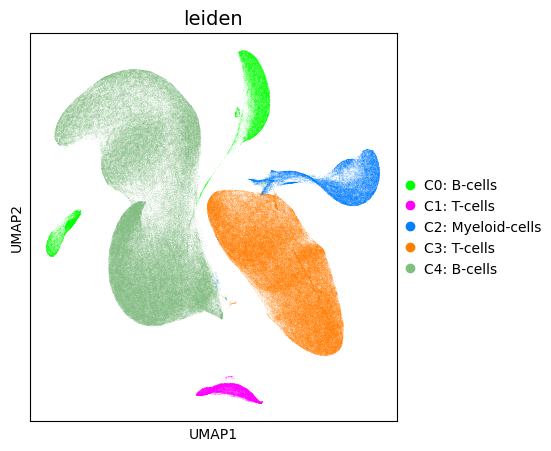

In [11]:
sc_plots.plot_umap(adata, keys="leiden", figsize=(5, 4),
                   save_path="../Figures/04_umap_clusters.png")

In [10]:
## %%time
# The input type is only needed if you don't use defaults "log2norm_counts"
# adata.X = adata.layers["your_pointlessly_renamed_log2norm_counts"].copy()

# This function calculates a hierarchichal clustering of the clusters and the DEGs in parallel
# NOTE: This function returns the object, because we might make changes, that inflict pars of the symbolic links
adata = sc_code.downstream_preprocessing(
    adata, ref_dict=adata.uns["genesets"]["provided_markers"])

INFO:sc_code.py:downstream_preprocessing - Run DEGs...
INFO:sc_code.py:downstream_preprocessing - DEG calculation took 953.55
INFO:sc_code.py:downstream_preprocessing - ################################################################################
Finished Downstream Preprocessing after 953.55 seconds
################################################################################


## Plot DEGs as dotplot

In [13]:
adata.uns["rank_genes_groups"]

,group,reference,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
16994,C0: B-cells,rest,KCNQ5,454.622772,1.953331,0.000000,0.000000,0.650834,0.033480
16995,C0: B-cells,rest,CDK14,451.340424,1.867490,0.000000,0.000000,0.850659,0.085902
16996,C0: B-cells,rest,TRIO,434.228729,1.298599,0.000000,0.000000,0.738389,0.060328
16997,C0: B-cells,rest,PRKCE,423.268219,1.569122,0.000000,0.000000,0.746833,0.069655
16998,C0: B-cells,rest,KHDRBS2,421.959229,1.486516,0.000000,0.000000,0.560730,0.027851
...,...,...,...,...,...,...,...,...,...
33983,C4: B-cells,rest,PTER,-0.100637,-0.018807,0.919839,0.920272,0.079099,0.077859
33984,C4: B-cells,rest,LINC00271,-0.097525,-0.001811,0.922310,0.922635,0.007079,0.007091
33985,C4: B-cells,rest,TAF15,0.082268,-0.040145,0.934434,0.934654,0.360524,0.341245
33986,C4: B-cells,rest,RNF19B,0.073144,-0.017293,0.941692,0.941803,0.053476,0.052735


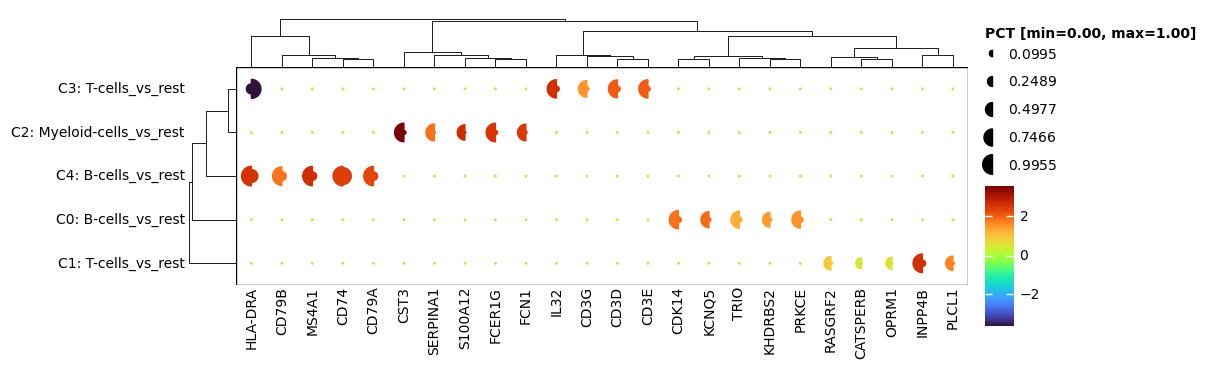

In [19]:
# NOTE: Via subset_kwargs you have full control over deg filtering and
#       via plot_clustered_dotplot_kwargs over the dotplot, 
#       check the function definitions for more info.
#       Alternative you can manipulate the deg dataframe directly and parse
#       it with sc_plots.plot_DEG_dotplot(..., deg_df=deg_df, ...)
sc_plots.plot_DEG_dotplot(
    adata,
    groupby="leiden",
    deg_key="rank_genes_groups",
    subset_kwargs={"n_genes": 5})  # for top 5

### EXCOURS: Caluclate DEGs with global external reference

When identifying differentially expressed genes (DEGs) for clusters in single-cell  
RNA-seq, choosing an **external, well-defined reference** (e.g., a curated cell type  
atlas or a high-quality control population) offers key advantages:

- **Consistency Across Clusters**  
  Every cluster is compared to the same baseline, avoiding dependence on
  arbitrary or unstable in-dataset references.

- **Clear Biological Interpretation**  
  DEGs reflect deviations from a biologically meaningful standard, improving
  interpretability.

- **Reduced Batch and Overclustering Artifacts**  
  If clustering is imperfect—e.g., the same cell type split into multiple clusters  
  e.g. due to batch effects—internal comparisons will blur true cell type markers.  
  An external baseline anchors the analysis, ensuring markers remain sharp even  
  when cluster identities are fragmented.

- **Balanced Statistical Comparisons**  
  Tests like Wilcoxon assume comparable group sizes; using all other clusters
  as a reference can create extreme size imbalances, reducing statistical power
  and inflating false positives. An external reference provides a controlled,
  consistent group size for fair comparisons.

In short, an external reference turns DEG analysis into a **context-aware,  
biologically grounded** approach that is more robust to clustering imperfections.

In [17]:
# As an example we take the cluster 0 here, but can also be data from different studys with clean and defined celltypes or whatever.
reference_adata = adata[adata.obs["leiden"] == "C0: B-cells"].copy()
# NOTE: because we merged the same cells, the obs names will be not unique anymore, so we make them unique
reference_adata.obs_names = [x + "_ref" for x in reference_adata.obs_names]
# Alternatively you can call the buggy adata function after merging
# adata_merged.obs_names_make_unique()

In [20]:
# Merge the two objects before deg calculation
adata_merged = sc_utils.merge_for_deg(
    adata,
    reference_adata,
    groupby="leiden",  # This key must be in the obs of the adata.
    reference_name="0_")

In [21]:
# Here we can see it worked we have 3102 cells with 0_ and 0
vc = adata_merged.obs["leiden"].value_counts()
display(vc[vc.index.isin(["0", "0_"])])
# and now we calculate the degs for each cluster vs te "0_", 
sc_utils.calc_DEGs(adata_merged, groupby="leiden", references="0_")
# and set the Degs into the original adata 
adata.uns["vs_reference_degs"] = adata_merged.uns["rank_genes_groups"].copy()
# and print a check that the all combinations of group and ref end in 0_
utils.join_categorical_columns(adata.uns["vs_reference_degs"], keys=["group", "reference"])["joined"].unique()

leiden
0_    38844
Name: count, dtype: int64

array(['C1: T-cells_0_', 'C2: Myeloid-cells_0_', 'C3: T-cells_0_',
       'C4: B-cells_0_'], dtype=object)

# Hallmark heatmap per cluster

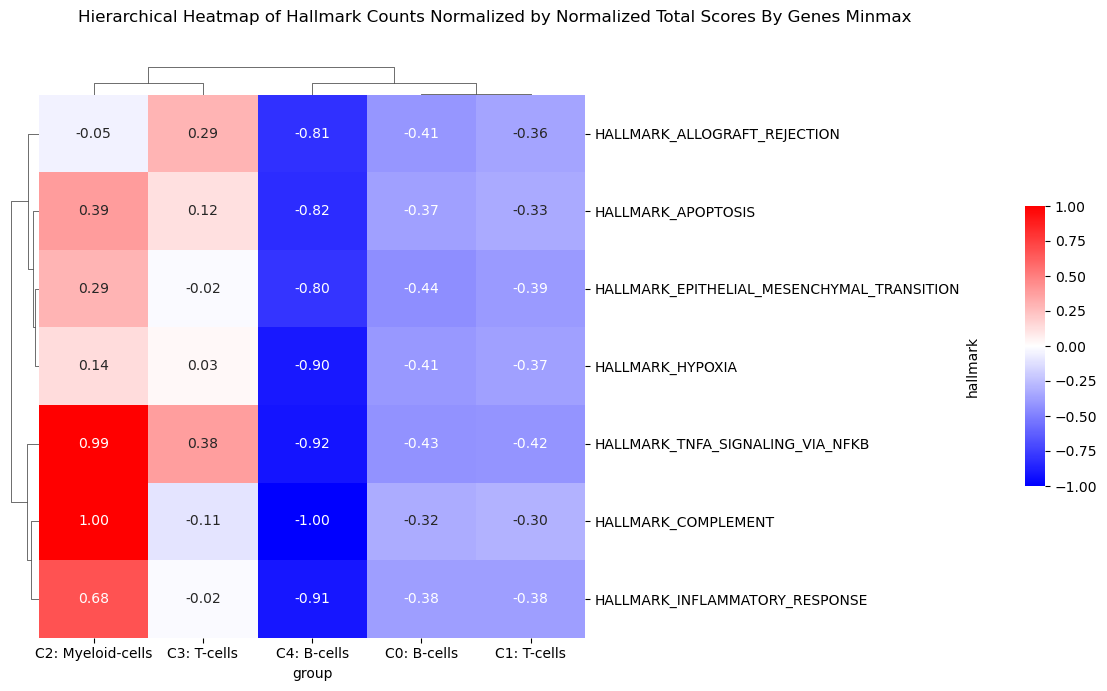

In [71]:
# We can show the significant hallmarks (significance by overlap with the DEGs)
# Options are:  "total_count",  "total_scores",  "total_normalized_by_genes", "normalized_total_scores_by_genes"
# For color scale improvement you can use a use_minmax scaler-

sc_plots.plot_hallmark_group_heatmap(
    adata, score_to_use="normalized_total_scores_by_genes",
    subset_pct=0.5,
    use_minmax=True,
    save_path="../Figures/04_hallmark_HEATMAP_ct.pdf"
)

# Condition Comparison plots

## Run the DEG calculation for the within the clusters to compare conditions

### Usage explanation for `run_cluster_condition_deg`

#### Overview

This function runs differential expression comparisons across clusters and conditions in a very flexible way.  
You can explicitly provide group-reference pairs, or let the function automatically generate them per cluster.

---

#### Key modes

- **Mode 1 (group_ref):** Provide exact `[group, reference]` pairs directly (e.g., `group_ref=[["0_A", "0_B"]]`).  
- **Mode 2 (groups + references):** Provide parallel lists of `groups` and `references`.  
- **Mode 4 (groups + single reference):** Provide `groups` list and a single string `references`, which will be broadcasted to match each group.  
- **Mode 5 (group_ref_cond):** Provide condition pairs to expand automatically across each cluster.  
- **Mode 6 (group_cond + reference_cond):** Specify conditions to compare across each cluster.  
- **Mode 7 (reference_cond only):** Default sweep: compare all other conditions to the reference in each cluster.  
- **Mode 9 (default sweep):** Compare every condition against every other condition within each cluster.

---

#### Example usage

```python
import pandas as pd
import numpy as np
import anndata as ad

# Create dummy AnnData
obs = pd.DataFrame({
    "leiden": ["0", "0", "1", "1", "2", "2"],
    "condition": ["A", "B", "A", "C", "A", "B"]
})
X = np.random.rand(obs.shape[0], 5)
adata = ad.AnnData(X=X, obs=obs)

# Example: explicit group_ref
res = run_cluster_condition_deg(adata, group_ref=[["0_A", "0_B"]])

# Example: groups and references
res = run_cluster_condition_deg(adata, groups=["0_A"], references=["0_B"])

# Example: auto expand per cluster
res = run_cluster_condition_deg(adata, group_cond="A", reference_cond="B")

# Example: default sweep comparing all conditions
res = run_cluster_condition_deg(adata)

In [36]:
adata

AnnData object with n_obs × n_vars = 572892 × 8497
    obs: 'orig.ident', 'ncount_rna', 'nfeature_rna', 'sample', 'sample_id', 'project_id', 'sample_type', 'disease', 'tissue', 'platform', 'disease_subtype', 'time_point', 'subject_id', 'age', 'gender', 'race', 'infection', 'disease_stage', 'mutation', 'predicted_cell_type', 'ct', 'sub.cluster', 'pct_gtex', 'pct_hpa', 'pct_hrt', 'pct_cellminer', 'pct_klijn', 'pct_IG_C_gene', 'pct_IG_C_pseudogene', 'pct_IG_J_gene', 'pct_IG_V_gene', 'pct_IG_V_pseudogene', 'pct_TR_C_gene', 'pct_TR_J_gene', 'pct_TR_J_pseudogene', 'pct_TR_V_gene', 'pct_TR_V_pseudogene', 'pct_lncRNA', 'pct_miRNA', 'pct_protein_coding', 'pct_ribozyme', 'pct_snRNA', 'pct_snoRNA', 'pct_pseudogenes_hg', 'n_unique', 'study_category', 'barcode', 'donor_id', 'gem_id', 'library_name', 'assay', 'sex', 'age_group', 'hospital', 'cohort_type', 'cause_for_tonsillectomy', 'is_hashed', 'preservation', 'annotation_level_1', 'annotation_level_1_probability', 'annotation_figure_1', 'annotation

In [40]:
%%time
cluster_key = "leiden"
condition_obs_key = "tissue"
conditions = ["blood", "tonsil"]
deg_key = "blood_vs_tonsil_per_cluster"

# sc_utils.run_cluster_condition_deg automatically merges the keys "leiden" and "condititon" 
# there is also utils.join_categorical_columns which also eighter returns a new col or alters the dataframe inplace
# utils.join_categorical_columns(adata.obs, [cluster_key, deg_obs_key], new_col=deg_obs_key, inplace=True)

sc_utils.calc_DEGs_multi_group(
    adata, cluster_key=cluster_key, condition_obs_key=condition_obs_key,
    group_ref_cond=[conditions], min_cells=100)
# NOTE: This will also be neccessary for the automated usage of "condition_obs_key" in the 
#       sc_plots.plot_DEG_dotplot( ..., condition_obs_key=condition_obs_key, ...)
#       sc_plots.plot_dotplot(..., condition_obs_key=condition_obs_key, ...)
#       sc_plots.plot_violin(..., condition_obs_key=condition_obs_key, ...)

CPU times: user 32min 20s, sys: 6min 58s, total: 39min 19s
Wall time: 8min 7s


In [41]:
adata.uns["tissue_per_leiden_rank_genes_groups"]

,group,reference,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,C2: Myeloid-cells_blood,C2: Myeloid-cells_tonsil,SERPINF1,-129.327545,-1.142115,0.000000,0.000000,0.033338,0.601083
1,C2: Myeloid-cells_blood,C2: Myeloid-cells_tonsil,HLA-DQA1,-127.625046,-2.472059,0.000000,0.000000,0.239194,0.881849
2,C2: Myeloid-cells_blood,C2: Myeloid-cells_tonsil,S100A8,120.475357,4.771376,0.000000,0.000000,0.923935,0.176219
3,C2: Myeloid-cells_blood,C2: Myeloid-cells_tonsil,S100A9,119.543098,4.105957,0.000000,0.000000,0.946088,0.267414
4,C2: Myeloid-cells_blood,C2: Myeloid-cells_tonsil,DNASE1L3,-113.654800,-1.266246,0.000000,0.000000,0.012115,0.425746
...,...,...,...,...,...,...,...,...,...
25477,C4: B-cells_blood,C4: B-cells_tonsil,NIPAL2,0.014331,0.015057,0.988566,0.989148,0.041297,0.041880
25478,C4: B-cells_blood,C4: B-cells_tonsil,TRGV5,-0.011080,0.000668,0.991160,0.991627,0.001064,0.001068
25479,C4: B-cells_blood,C4: B-cells_tonsil,IL17RA,0.008936,0.021608,0.992870,0.993221,0.049670,0.050641
25480,C4: B-cells_blood,C4: B-cells_tonsil,FARP2,-0.001452,0.043365,0.998842,0.999077,0.087987,0.091816


## Split Dotplot

### Split DEG Dotplot

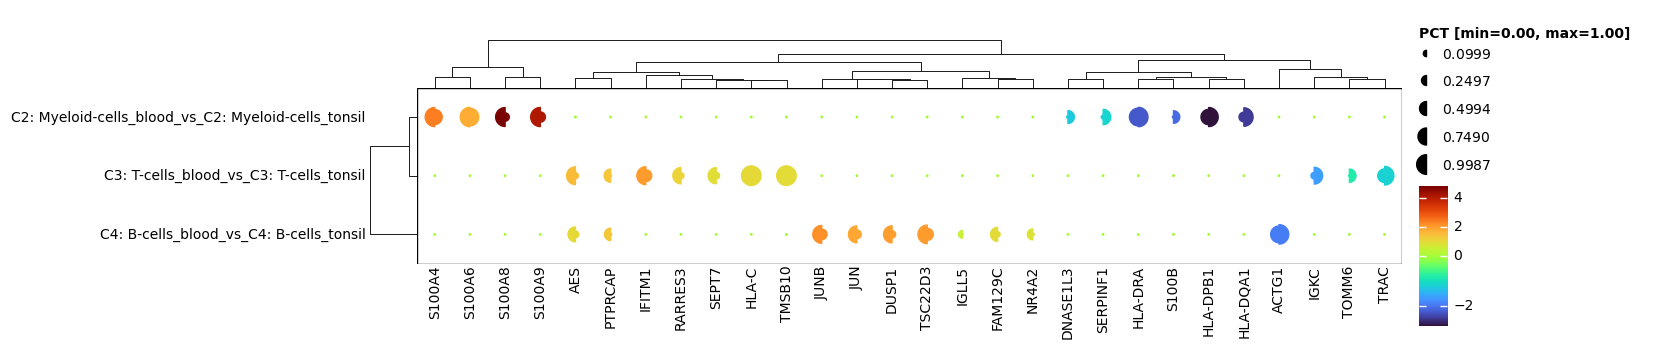

In [44]:
# NOTE: Via subset_kwargs you have full control over deg filtering and
#       via plot_clustered_dotplot_kwargs over the dotplot, 
#       check the function definitions for more info.
sc_plots.plot_DEG_dotplot(
    adata,
    deg_df=adata.uns["tissue_per_leiden_rank_genes_groups"],
    subset_kwargs={"n_genes": 10},
    plot_group_dotplot_kwargs={
        "save_path": "../Figures/04_split_dotplot_1_vs_1.pdf"}
)

### Split Gene Dotplot

When working with combined categorical variables, such as clusters  
(e.g., leiden or louvain, referred to here as `cluster_key`) and  
experimental conditions (e.g., control vs treatment, `condition_obs_key`),  
it’s often necessary to analyze differential expression within each  
joint group.  

The idea is to combine these keys into a single composite key  
(`deg_obs_key`) so that each unique combination of cluster and condition  
defines its own group. You can then calculate differentially expressed  
genes (DEGs) between groups, or against a global reference, using this  
combined annotation.  

After combining, assign a new key (e.g., `deg_key`) to store the DEG  
results. Finally, run your downstream analysis function — for example,  
a signature scoring or marker gene identification step — on the DEGs  
for each combined group.  

This approach ensures that both cluster-specific effects and  
condition-specific effects are captured together, rather than analyzed  
independently, which can mask important biological signals or  
interactions.  

**Summary of steps**  

- **Combine keys and Calculate DEGs:**  
  run the run_cluster_condition_deg().  


- **Run function:**  
  Call your function (e.g., gene set scoring, enrichment, etc.) using  
  the DEGs from `deg_key`.  


In [47]:
# Get some markers to plot
ct_ref = sc_utils.get_valide_ref_dicts(adata, adata.uns["genesets"]["cell_type_markers"])[0]
ref = ct_ref["macrophage_cells"]

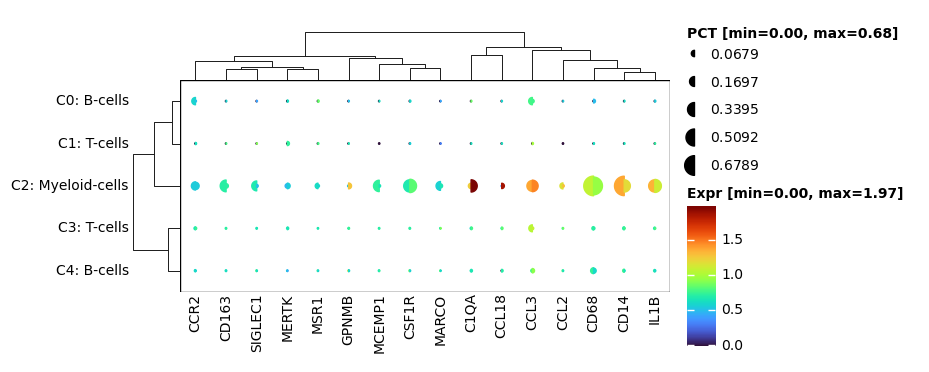

In [49]:
# Full plot
sc_plots.plot_dotplot(
    adata=adata,
    keys=ref,
    groupby="leiden",
    condition_obs_key=condition_obs_key,
    vs=conditions)

### Subsetting adata objects to conditions/DEGs only

Showing only DEGs in a dotplot makes sense because it removes noise  
from non-informative genes, focuses the visual on biologically  
relevant differences, and improves interpretability. Non-DEGs often  
clutter the axis and dilute signal, while DEGs highlight actual  
transcriptional changes across conditions or clusters.


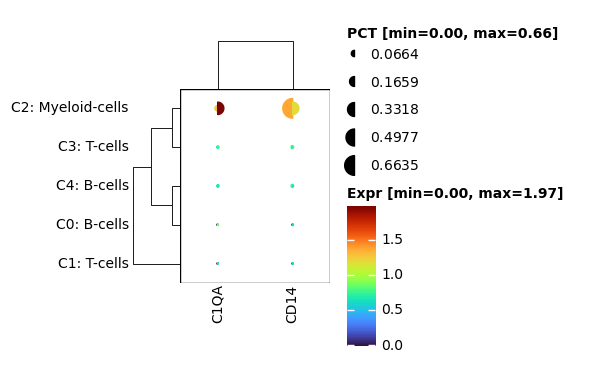

In [52]:
# Subsetted to significant genes and clusters only
# NOTE: the filtering is unstringent like before, it's just a showcase
adata_out, retained_ref = sc_utils.get_adata_subset(
    adata=adata,
    vs=conditions,
    ref=ref,
    condition_obs_key=condition_obs_key,
    # layer="log2norm_counts",
    layer="log2norm_counts",
    cluster_key=cluster_key,
    subset_to_degs=True,
    mask_non_significant_groups=True,
    scale_axis=None,
    when_to_scale="after",
    kwarg_filter_genes={"perc": 0.1, "p_val_cutoff": 1e-3, "lfc": 0.5},
    kwarg_filter_cells={"perc": 0.1, "p_val_cutoff": 1e-3, "lfc": 0.5},
)

sc_plots.plot_dotplot(
    adata=adata_out,
    keys=retained_ref,
    groupby="leiden",
    condition_obs_key=condition_obs_key,
    vs=conditions,
)

### EXCOURSE: Transforming for visibility

Transforming values to a common scale (e.g. 0–1 via min-max) can mislead if  
the original data range lacks meaningful magnitude. A range like 0–7 and one  
like 1e-6–1e-5 will look identical post-transformation, despite vastly  
different implications. If the raw range doesn't carry interpretive weight—  
biological or statistical—then scaling just for visual parity is unjustified  
and can obscure the actual importance (or irrelevance) of the variation.

/ssd/projects/Proximap/mambaforge/scanpy_stable_25_04_latest/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


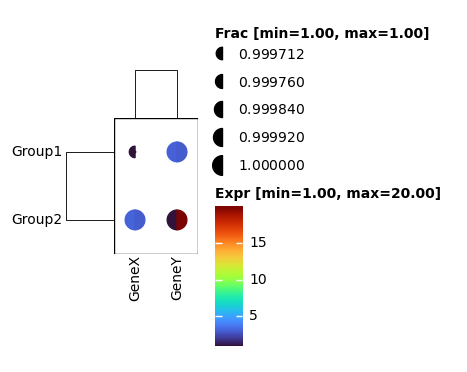

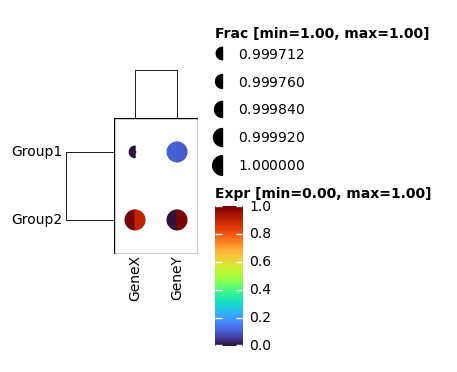

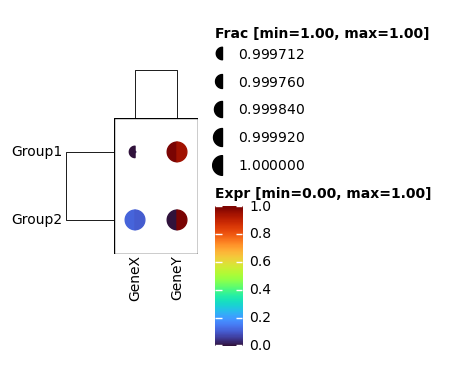

In [20]:
# #########################################################
# Create synthetic AnnData with 2 groups, 2 conditions, 2 genes
gene_names = ["GeneX", "GeneY"]
group_labels = ["Group1", "Group2"]
condition_labels = ["Cond1", "Cond2"]

num_cells = 50004
adata_demo = sc.AnnData(
    X=np.zeros((num_cells, len(gene_names))),
    obs=pd.DataFrame({
        "group_id": np.repeat(group_labels, num_cells // 2),
        "condition_id": np.tile(np.repeat(condition_labels, num_cells // 4), 2),
    }),
    var=pd.DataFrame(index=gene_names),
)
adata_demo.obs["group_id"] = adata_demo.obs["group_id"].astype("category")
adata_demo.obs["condition_id"] = adata_demo.obs["condition_id"].astype("category")
# #########################################################
# Introduce contrasting expression differences
# GeneX: large difference between conditions in Group1
# GeneY: small difference between conditions in Group2
rng = np.random.default_rng(42)

# #########################################################
# Assign base expression with differences between conditions/groups
adata_demo.X[:, 0] = np.select(
    [
        (adata_demo.obs["group_id"] == "Group1")
        & (adata_demo.obs["condition_id"] == "Cond1"),
        (adata_demo.obs["group_id"] == "Group1")
        & (adata_demo.obs["condition_id"] == "Cond2"),
        (adata_demo.obs["group_id"] == "Group2")
        & (adata_demo.obs["condition_id"] == "Cond1"),
        (adata_demo.obs["group_id"] == "Group2")
        & (adata_demo.obs["condition_id"] == "Cond2"),
    ],
    [1, 1, 3.2, 3.0],
) + rng.normal(0, 0.3, adata_demo.shape[0])

adata_demo.X[:, 1] = np.select(
    [
        (adata_demo.obs["group_id"] == "Group1")
        & (adata_demo.obs["condition_id"] == "Cond1"),
        (adata_demo.obs["group_id"] == "Group1")
        & (adata_demo.obs["condition_id"] == "Cond2"),
        (adata_demo.obs["group_id"] == "Group2")
        & (adata_demo.obs["condition_id"] == "Cond1"),
        (adata_demo.obs["group_id"] == "Group2")
        & (adata_demo.obs["condition_id"] == "Cond2"),
    ],
    [3.1, 3.0, 1, 20],
) + rng.normal(0, 0.05, adata_demo.shape[0])

# #########################################################
# Default
sc_plots.plot_dotplot(
    adata=adata_demo,
    keys=["GeneX", "GeneY"],
    groupby="group_id",
    condition_obs_key="condition_id",
    vs=["Cond1", "Cond2"],
)
# #########################################################
# Scale Columns - Overestimates Group2 GeneX
sc_plots.plot_dotplot(
    adata=adata_demo,
    keys=["GeneX", "GeneY"],
    groupby="group_id",
    condition_obs_key="condition_id",
    vs=["Cond1", "Cond2"],
    plot_group_dotplot_kwargs={"minmax_scale_axis": 0},
)
# #########################################################
# Scale Rows - Overestimates Group1 GeneY
sc_plots.plot_dotplot(
    adata=adata_demo,
    keys=["GeneX", "GeneY"],
    groupby="group_id",
    condition_obs_key="condition_id",
    vs=["Cond1", "Cond2"],
    plot_group_dotplot_kwargs={
        "minmax_scale_axis": 1,
        },
    
)


##  Violins

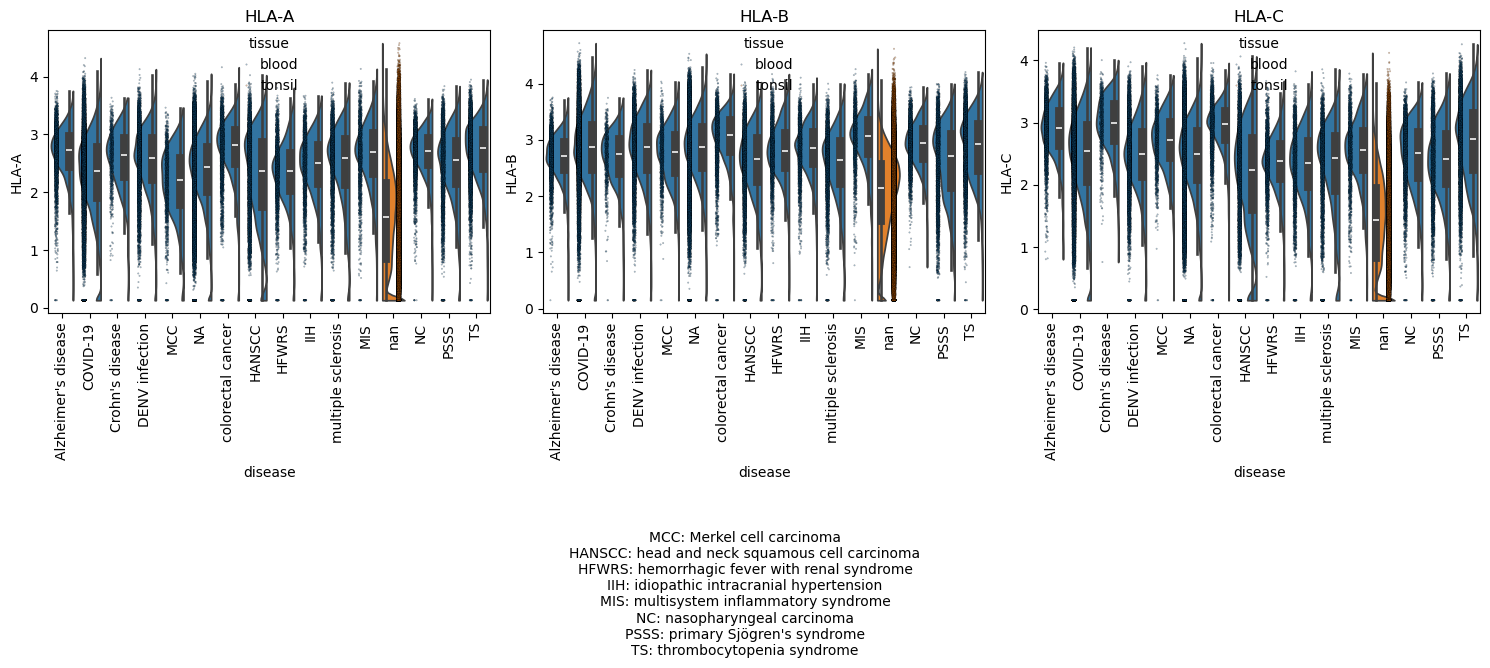

In [53]:
sc_plots.plot_violin(
    adata,
    ["HLA-A", "HLA-B", "HLA-C"], 
    groupby="disease",
    condition_obs_key=condition_obs_key,
    conditions=conditions,
    stripplot_kwargs={"size": 1, "alpha": .3},
    base_figsize=(5, 5)
)

## Condition Umap side by side

In [56]:
adata

AnnData object with n_obs × n_vars = 572892 × 8497
    obs: 'orig.ident', 'ncount_rna', 'nfeature_rna', 'sample', 'sample_id', 'project_id', 'sample_type', 'disease', 'tissue', 'platform', 'disease_subtype', 'time_point', 'subject_id', 'age', 'gender', 'race', 'infection', 'disease_stage', 'mutation', 'predicted_cell_type', 'ct', 'sub.cluster', 'pct_gtex', 'pct_hpa', 'pct_hrt', 'pct_cellminer', 'pct_klijn', 'pct_IG_C_gene', 'pct_IG_C_pseudogene', 'pct_IG_J_gene', 'pct_IG_V_gene', 'pct_IG_V_pseudogene', 'pct_TR_C_gene', 'pct_TR_J_gene', 'pct_TR_J_pseudogene', 'pct_TR_V_gene', 'pct_TR_V_pseudogene', 'pct_lncRNA', 'pct_miRNA', 'pct_protein_coding', 'pct_ribozyme', 'pct_snRNA', 'pct_snoRNA', 'pct_pseudogenes_hg', 'n_unique', 'study_category', 'barcode', 'donor_id', 'gem_id', 'library_name', 'assay', 'sex', 'age_group', 'hospital', 'cohort_type', 'cause_for_tonsillectomy', 'is_hashed', 'preservation', 'annotation_level_1', 'annotation_level_1_probability', 'annotation_figure_1', 'annotation

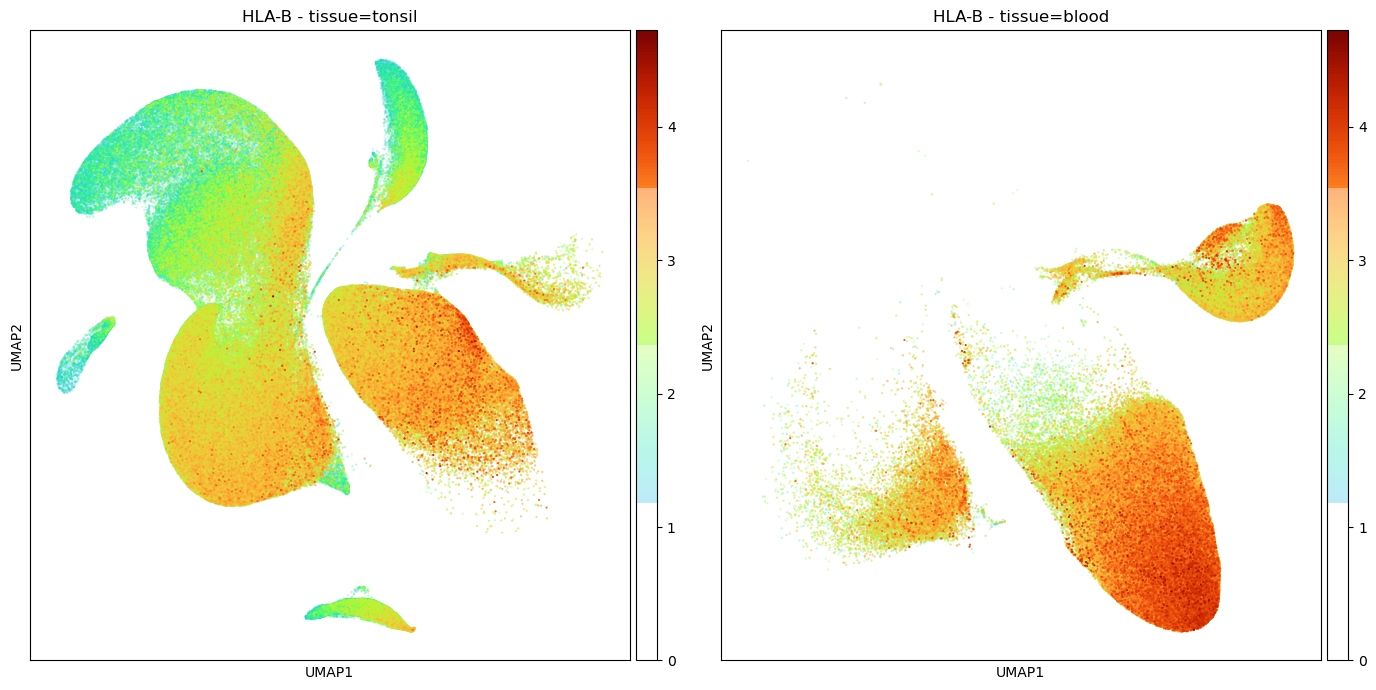

In [62]:
sc_plots.plot_umap_sbs(
    adata,
    genes=["HLA-B"],
    groupby="tissue",  # Conditon or whatever catigorical you want to plot side by side
    groups=None,  # This could be used to specify which of the conditions you want to plot
    cmap=sc_plots.get_colormap(  # This is a nice little helper that fades the alpha channel of a cmap
        "turbo", 
        fade_alpha=True, alphas=[0] * 50 + [.3] * 50 + [.6] * 50 + [1] * 50),
    base_figsize=(7, 7), s=10)

# Volcano plots

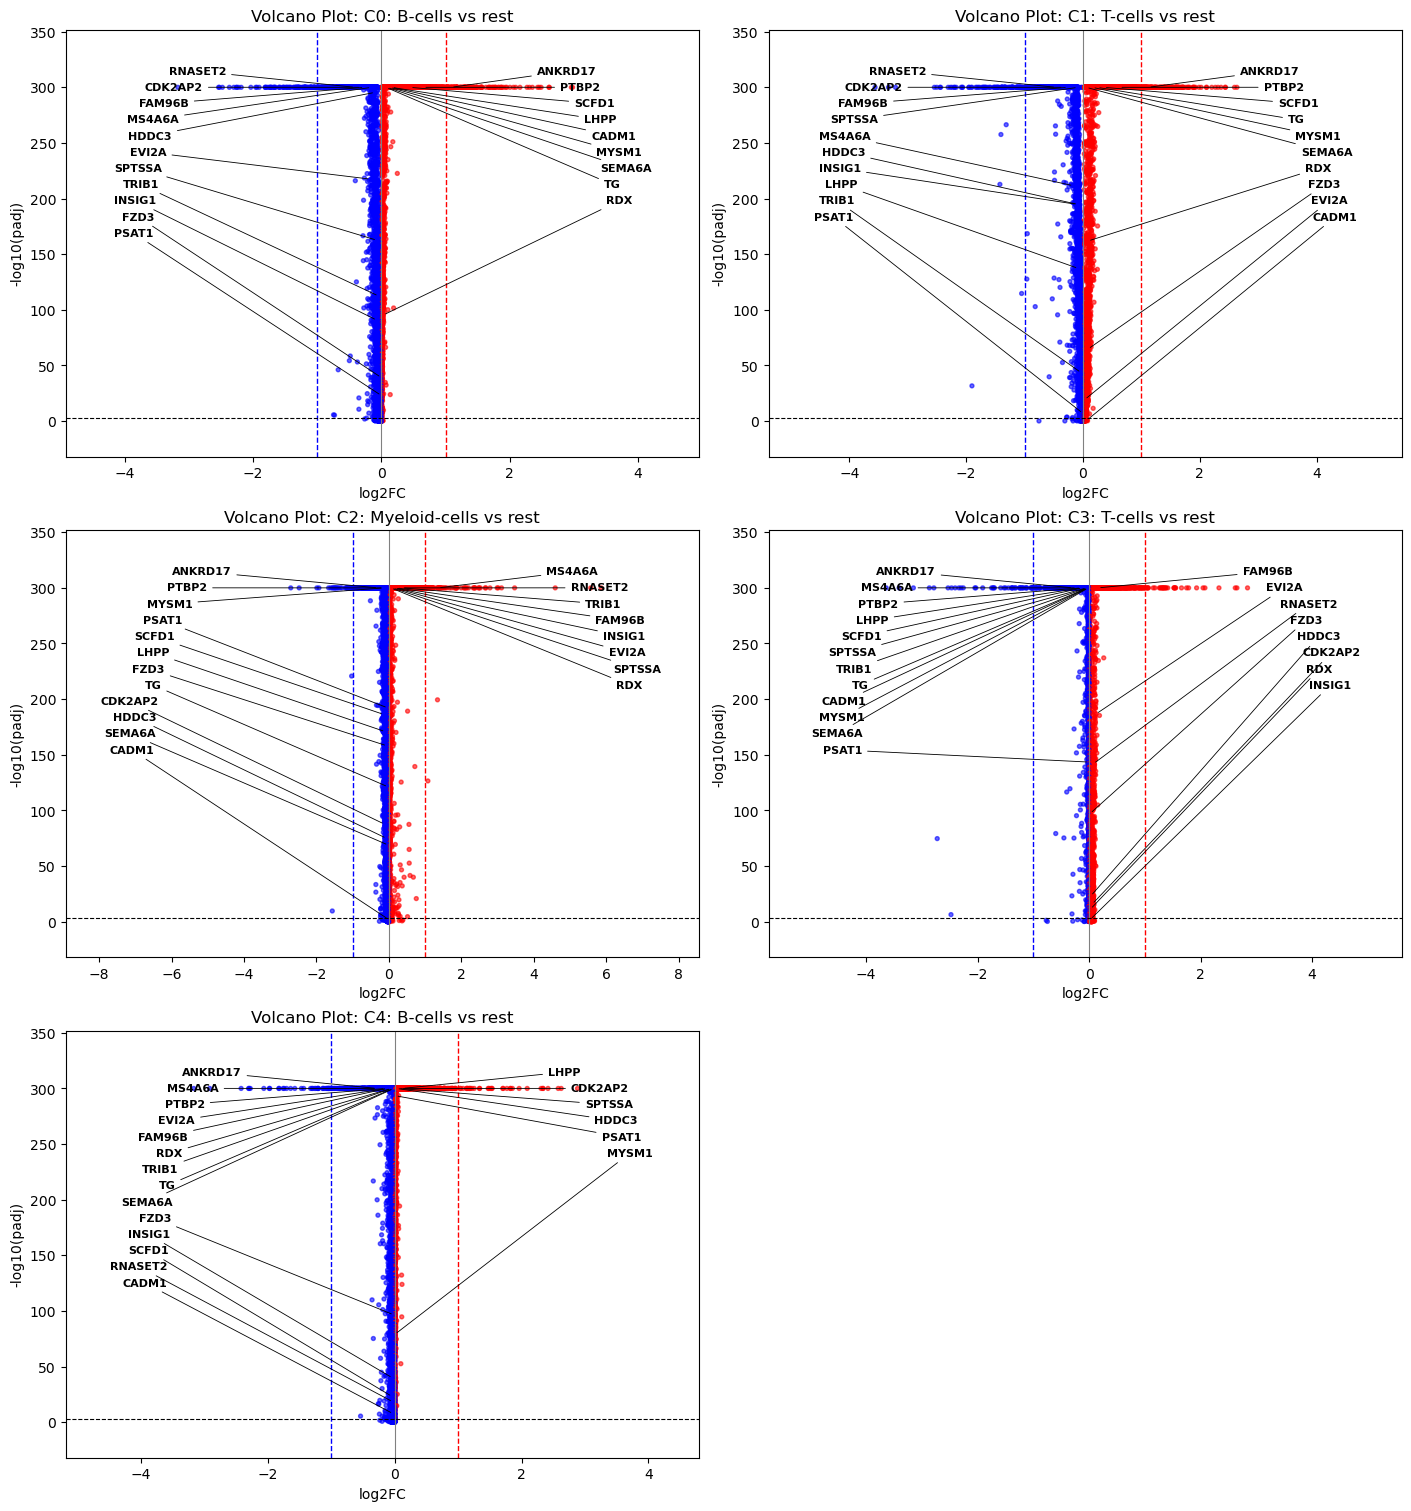

In [63]:
# Here we use random genes to show the feature, default is top 5 up and down
deg_df = adata.uns["rank_genes_groups"]
sc_plots.plot_volcano(
    deg_df, genes=np.array(
        deg_df["names"].tolist())[np.random.randint(0, len(deg_df) - 1, 20).tolist()],
    spacing_factor = 1.5, #  1.15,
    label_offset_px = 20, # 20.0,
    text_shift_px = 10) # 12.0,)

As we can see, the adjusted p-values are crazy inflated,  
you should use our permutation test to calculate the degs,  
this also don't enforces you to have so many different filters.

# Full downstream plots and csvs

In [64]:
# For reference check the docs of the sc_config or the code directly
# Here we set parameters to don't plot too much, it's just a showcase.
config = adata.uns["config"]

config["to_plot"]["down"]["visualize_leiden_umap"] = True
config["to_plot"]["cl"]["visualize_embedding_density_umap"] = True
config["to_plot"]["down"]["visualize_qc_umap"] = True  # HERE
config["to_plot"]["cl"]["visualize_pca_variance_ratio"] = True
# ############################################################################################
# Visualize heatmaps based on medioids subclustering
config["to_plot"]["down"]["heatmaps"]["visualize"] = False

config["to_plot"]["down"]["cluster_violins"]["visualize"] = True
config["to_plot"]["down"]["cluster_dotplot"]["visualize"] = True
config["to_plot"]["down"]["cluster_dotplot"]["marker_mod"] = ["rna"]
config["to_plot"]["down"]["cluster_dotplot"]["marker_mod_per_cluster"] = ["rna"]


# Plot the gradient continuosF
config["to_plot"]["down"]["gradients_umap"]["continuos"] = True  # HERE
# Optionally plot the gradient umaps in discretized version
config["to_plot"]["down"]["gradients_umap"]["discretize"] = False

config["to_plot"]["down"]["gradients_umap"]["num_ref_genes"] = 2
config["to_plot"]["down"]["gradients_umap"]["num_DEGs"] = 3

##############
# use highly variable
config["to_plot"]["down"]["gradients_umap"]["include_highly_variable"] = True  # HERE

config["to_plot"]["down"]["gradients_umap"]["num_highly_variable"] = 2


# Save tables as different data types 
config["general"]["save_df_types"] = [".csv", ".xlsx"]


In [65]:
# Dummy subset to cluster 0 and 4 for faster plotting
clusters_to_use = ["C0: B-cells", "C2: Myeloid-cells"]
adata_ = adata[adata.obs["leiden"].isin(clusters_to_use)].copy()
adata_.uns["rank_genes_groups"] = adata_.uns["rank_genes_groups"][adata_.uns["rank_genes_groups"]["group"].isin(clusters_to_use)].copy()

In [66]:
# THIS HAS TO BE USED WITH EXTREME CONCIOUSNESS and only used for plotting arguments or useless scanpy thing like overwriting "use_raw" = False
sc_config.update_key_in_config(adata_.uns["config"], key_to_update="cmap", new_value="turbo")

INFO:sc_code.py:downstream_preprocessing - ################################################################################
Finished Downstream Preprocessing after 0.00 seconds
################################################################################
INFO:sc_code.py:downstream_preprocessing - ################################################################################
Finished Downstream Preprocessing after 0.00 seconds
################################################################################
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - This set of figures visualizes Features in the UMAP Space
INFO:sc_code.py:run_downstream - This set of figures visualizes Features in the UMAP 

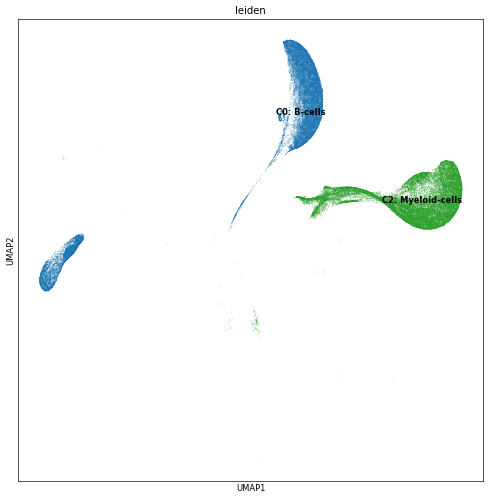

INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - This Figure shows Density of cells for each Sample or Condition
INFO:sc_code.py:run_downstream - This Figure shows Density of cells for each Sample or Condition
INFO:sc_code.py:run_downstream - it is saved as: umap_density_sample_type_.pdf
INFO:sc_code.py:run_downstream - it is saved as: umap_density_sample_type_.pdf
INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - ################################################################################


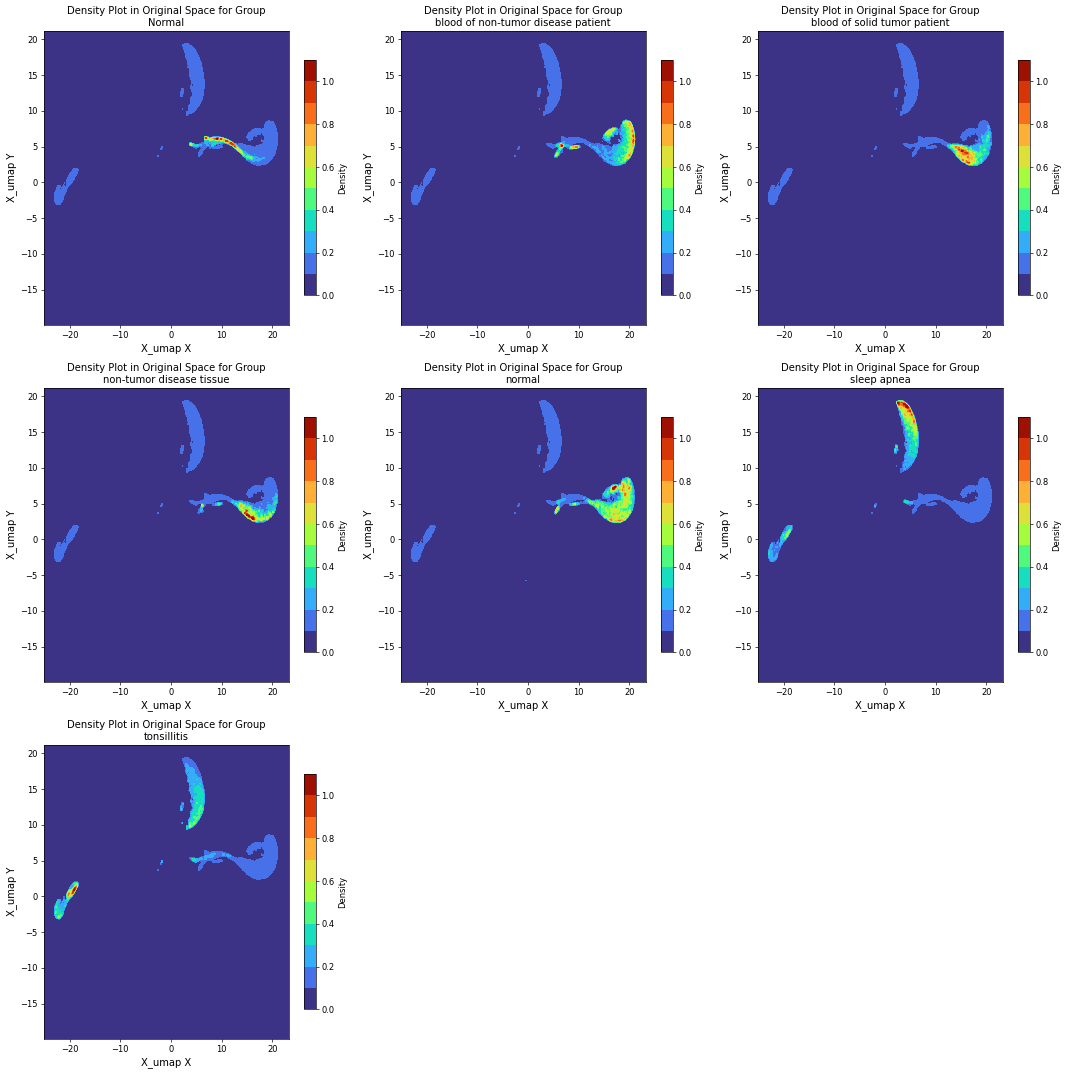

INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - This Figure shows Density of cells for each Sample or Condition
INFO:sc_code.py:run_downstream - This Figure shows Density of cells for each Sample or Condition
INFO:sc_code.py:run_downstream - it is saved as: umap_density_study_category_.pdf
INFO:sc_code.py:run_downstream - it is saved as: umap_density_study_category_.pdf
INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - ################################################################################


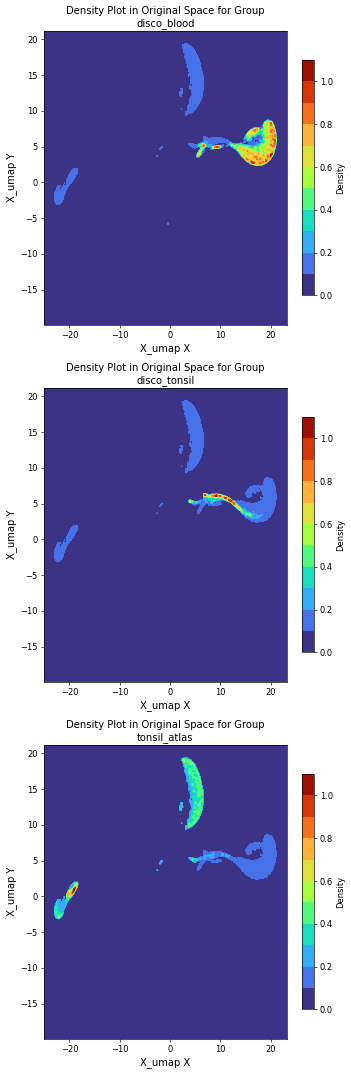

INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - This Figure shows Density of cells for each Sample or Condition
INFO:sc_code.py:run_downstream - This Figure shows Density of cells for each Sample or Condition
INFO:sc_code.py:run_downstream - it is saved as: umap_density_platform_.pdf
INFO:sc_code.py:run_downstream - it is saved as: umap_density_platform_.pdf
INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - ################################################################################


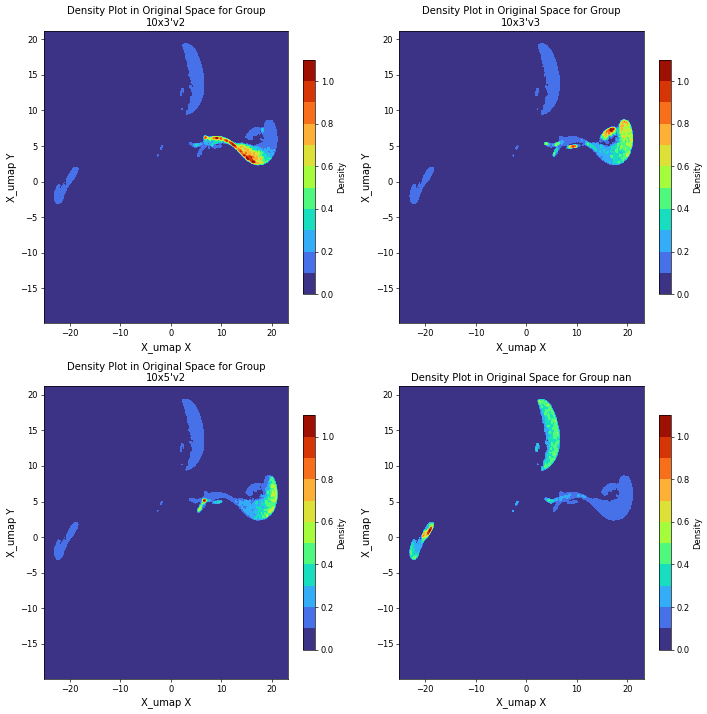

INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - This Figure shows Quality Control for Cells
INFO:sc_code.py:run_downstream - This Figure shows Quality Control for Cells
INFO:sc_code.py:run_downstream - it is saved as: umap__qc.pdf
INFO:sc_code.py:run_downstream - it is saved as: umap__qc.pdf
INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - ################################################################################


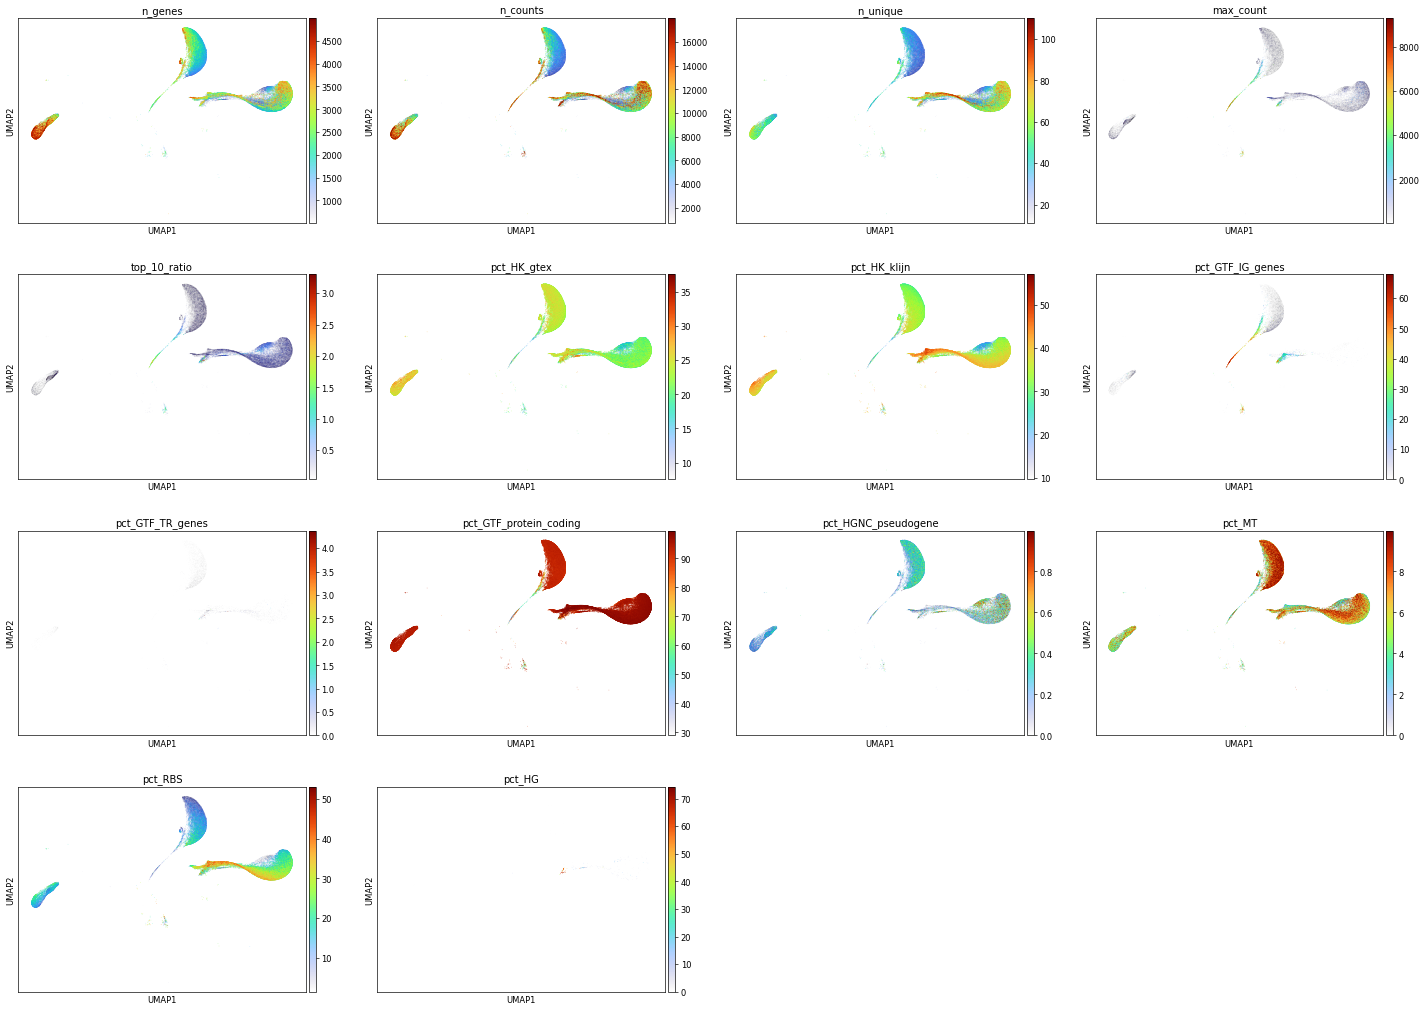

INFO:sc_plots.py:continuos_umap_helper - ################################################################################
INFO:sc_plots.py:continuos_umap_helper - ################################################################################
INFO:sc_plots.py:continuos_umap_helper - This Shows C0: B-cells_DEGs Genes gradients for each cell over the UMAP
INFO:sc_plots.py:continuos_umap_helper - This Shows C0: B-cells_DEGs Genes gradients for each cell over the UMAP
INFO:sc_plots.py:continuos_umap_helper - It is saved as: umap_C0: B-cells_DEGs_continuos.pdf
INFO:sc_plots.py:continuos_umap_helper - It is saved as: umap_C0: B-cells_DEGs_continuos.pdf
INFO:sc_plots.py:continuos_umap_helper - ################################################################################
INFO:sc_plots.py:continuos_umap_helper - ################################################################################


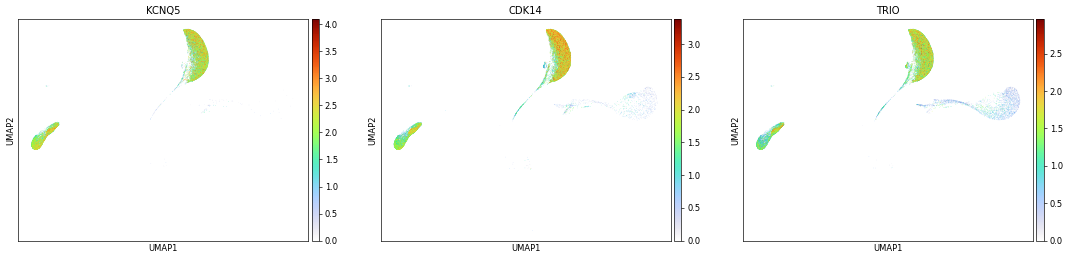

INFO:sc_plots.py:continuos_umap_helper - ################################################################################
INFO:sc_plots.py:continuos_umap_helper - ################################################################################
INFO:sc_plots.py:continuos_umap_helper - This Shows C2: Myeloid-cells_DEGs Genes gradients for each cell over the UMAP
INFO:sc_plots.py:continuos_umap_helper - This Shows C2: Myeloid-cells_DEGs Genes gradients for each cell over the UMAP
INFO:sc_plots.py:continuos_umap_helper - It is saved as: umap_C2: Myeloid-cells_DEGs_continuos.pdf
INFO:sc_plots.py:continuos_umap_helper - It is saved as: umap_C2: Myeloid-cells_DEGs_continuos.pdf
INFO:sc_plots.py:continuos_umap_helper - ################################################################################
INFO:sc_plots.py:continuos_umap_helper - ################################################################################


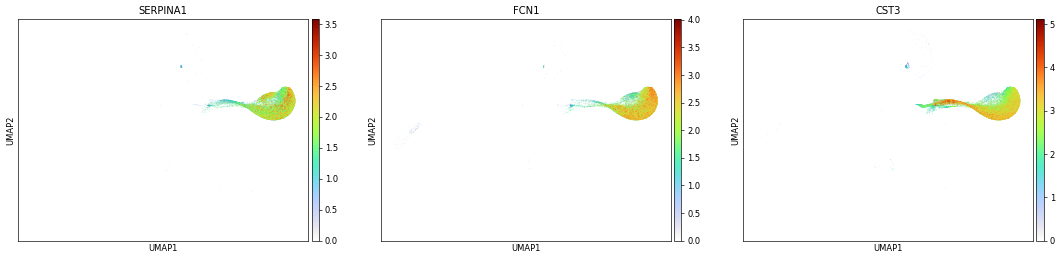

INFO:sc_plots.py:continuos_umap_helper - ########################################
INFO:sc_plots.py:continuos_umap_helper - ########################################
INFO:sc_plots.py:continuos_umap_helper - This Shows top2_highly_variable Genes gradients for each cell over the UMAP
INFO:sc_plots.py:continuos_umap_helper - This Shows top2_highly_variable Genes gradients for each cell over the UMAP
INFO:sc_plots.py:continuos_umap_helper - It is saved as: umap_top2_highly_variable_continuos.pdf
INFO:sc_plots.py:continuos_umap_helper - It is saved as: umap_top2_highly_variable_continuos.pdf
INFO:sc_plots.py:continuos_umap_helper - ########################################
INFO:sc_plots.py:continuos_umap_helper - ########################################


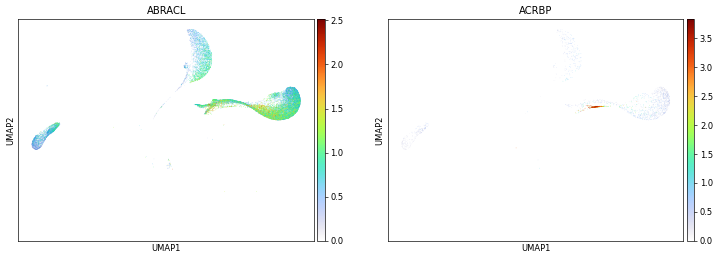

INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - This Shows Dotplots for the DEGs and/or Markers per Cluster.
INFO:sc_code.py:run_downstream - This Shows Dotplots for the DEGs and/or Markers per Cluster.
INFO:sc_code.py:run_downstream - The figures are saved in /downstream/Dotplots/
INFO:sc_code.py:run_downstream - The figures are saved in /downstream/Dotplots/
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - ###

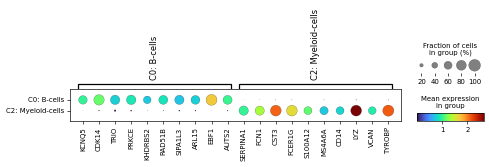

INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - ################################################################################
INFO:sc_code.py:run_downstream - This Shows Dotplots for the markers per Cluster.
INFO:sc_code.py:run_downstream - This Shows Dotplots for the markers per Cluster.
INFO:sc_code.py:run_downstream - NOTE: It is possible to subset these and you want it
INFO:sc_code.py:run_downstream - NOTE: It is possible to subset these and you want it
INFO:sc_code.py:run_downstream -       please ask your Collaboration partner of choice.
INFO:sc_code.py:run_downstream -       please ask your Collaboration partner of choice.
INFO:sc_code.py:run_downstream - The figures are saved in /downstream/Dotplots/markers/
INFO:sc_code.py:run_downstream - The figures are saved in /downstream/Dotplots/markers/
INFO:sc_code.py:run_downstream - ###################################################

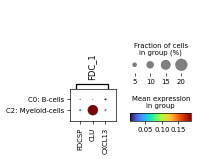

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Plasma.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Plasma.pdf


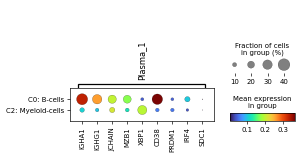

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Naive_B.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Naive_B.pdf


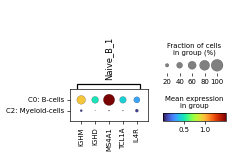

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_GC_B_DZ.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_GC_B_DZ.pdf


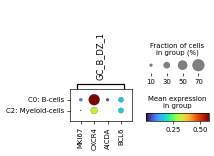

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_GC_B_LZ.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_GC_B_LZ.pdf


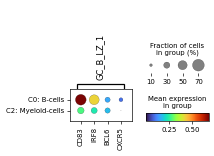

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Memory_B.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Memory_B.pdf


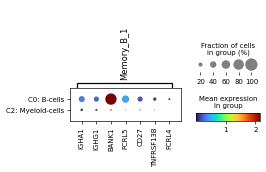

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Transitional_B.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Transitional_B.pdf


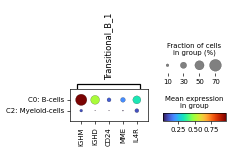

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_DC.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_DC.pdf


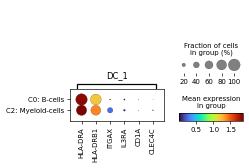

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Epithelial.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Epithelial.pdf


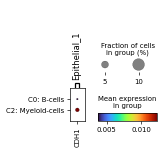

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Granulocyte.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Granulocyte.pdf


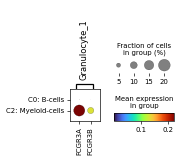

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Macrophage.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Macrophage.pdf


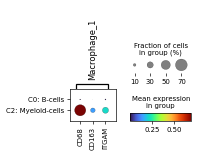

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Monocyte.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Monocyte.pdf


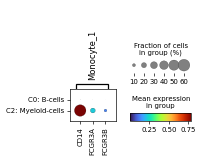

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Myeloid.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Myeloid.pdf


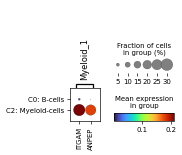

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_T_cell.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_T_cell.pdf


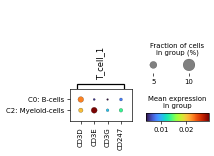

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_CD4_T.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_CD4_T.pdf


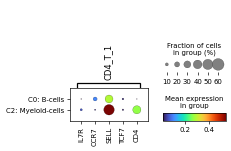

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_CD8_T.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_CD8_T.pdf


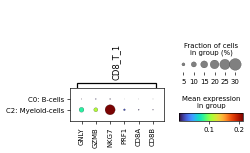

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_NK.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_NK.pdf


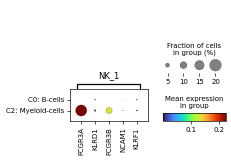

INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Immune_general.pdf
INFO:sc_plots.py:plot_ref_dotplots - The figure is saved as rna_cluster_marker_expression_group_Immune_general.pdf


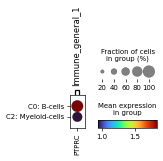

INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - This Shows Stacked Violinplots for the DEGs and/or Markers per Cluster.
INFO:sc_code.py:run_downstream - This Shows Stacked Violinplots for the DEGs and/or Markers per Cluster.
INFO:sc_code.py:run_downstream - The figures are saved in /downstream/Violinplots/
INFO:sc_code.py:run_downstream - The figures are saved in /downstream/Violinplots/
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_

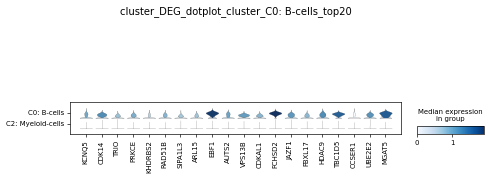

INFO:sc_plots.py:plot_per_group_stacked_violins - The figure is saved as cluster_DEG_dotplot_cluster_C2: Myeloid-cells_top20.pdf
INFO:sc_plots.py:plot_per_group_stacked_violins - The figure is saved as cluster_DEG_dotplot_cluster_C2: Myeloid-cells_top20.pdf


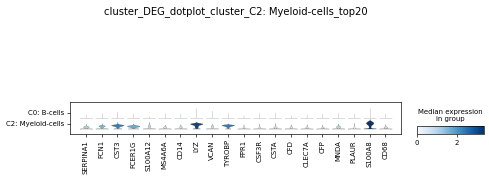

INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - Saving Cluster stats at: analysis/DEGs/
INFO:sc_code.py:run_downstream - Saving Cluster stats at: analysis/DEGs/
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - ########################################################################################################################
INFO:sc_code.py:run_downstream - ###################################################

In [67]:
%%time


# Define rcParams for customization, notebook showing is figure.dpi, reduce to not overload the nootebook sizes
# BUT!!!!!!! Here we convert the notebook to a html file to send it to the collaborators, reducing the figure.dpi
# will result in bad quality plots, which you don't want to copy out of the html report, so use also 400
plt.rcParams.update({
    # "figure.figsize": (8, 6),  # Figure size in inches
    "savefig.dpi": 400,       # Dots per inch for saved figures
    "figure.dpi": 100,       # Dots per inch for saved figures
    #"axes.titlesize": 16,     # Title font size
    #"axes.labelsize": 14,     # Label font size
    #"xtick.labelsize": 12,    # X-axis tick label size
    #"ytick.labelsize": 12     # Y-axis tick label size
})


# And the automated Plotting/CSV saving close to everything adjustable via the config
# (thats why you will need some time to familiarize yourself with the config!)
# NOTE: It is actually not strictly necessary to run the downstream_preprocessing,
#       because it is handled also by the function. But for the previous plots we needed the DEGs.
with plt.rc_context({'figure.dpi': 60, 'savefig.dpi': 60}):
    sc_code.run_downstream(adata_, {})

In [70]:
# Save the DEGs as csv
sc_utils.get_DEG_gene_csvs(adata)

# Rest

In [72]:
sc_code.save_h5ad(adata, "../data/04_tonsil_blood_DISCO_clustered_downstream_processed.h5ad", compression="lzf")